# Methodology Figures — ADA Healthcare Access DiD Study

Produces:
- **Figure 3** — Supplement Selection Rate by Year
- **Figure 4** — Parallel Trends Plot (Pre-ADA weighted group means)
- **Figure 5** — Pre-Trend Coefficient Plot (identification figure)
- **Figure 6** — Event Study (full 1984–1996)

**Input:** `data/clean/nhis_analysis_ready.csv`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

DATA = Path('/Users/tanishagauns/Desktop/Capstone Project/data/clean/nhis_analysis_ready.csv')
OUT  = Path('/Users/tanishagauns/Desktop/Capstone Project/Nhis')

df_full = pd.read_csv(DATA, low_memory=False)
df_full['year'] = df_full['year'].astype(int)

# Analysis sample
ana = df_full[
    (df_full['year'].between(1983, 1996)) &
    (df_full['disabled'].isin([0.0, 1.0]))
].copy()
ana['dv12_clean'] = (
    ana['dv12']
    .where(~ana['dv12'].isin([97, 98, 99, 997, 998, 999]), other=np.nan)
    .clip(upper=96)
)
ana['treated'] = ana['disabled'].astype(int)
ana['year_c']  = pd.Categorical(ana['year'])

print(f'Analysis sample: {len(ana):,} rows')
print(f'Years: {ana["year"].min()}–{ana["year"].max()}')

---
## Figure 3 — Supplement Selection Rate by Year

In [ ]:
study = df_full[df_full['year'].between(1983, 1996)].copy()
supp = (
    study.groupby('year')
    .apply(lambda g: pd.Series({
        'n_supp' : g['disabled'].isin([0.0, 1.0]).sum(),
        'n_total': len(g)
    }))
    .reset_index()
)
supp['pct'] = supp['n_supp'] / supp['n_total'] * 100

years = supp['year'].values
pcts  = supp['pct'].values

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Stable band
ax.axhspan(9.4, 10.9, color='#d5e8f7', alpha=0.45, zorder=0, label='Stable band (9.4%–10.9%)')

# Bars
bar_colors = ['#2980b9' if yr <= 1989 else '#e67e22' for yr in years]
bars = ax.bar(years, pcts, color=bar_colors, width=0.65, zorder=3, edgecolor='white', linewidth=0.5)

# Value labels on bars
for bar, pct in zip(bars, pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.08,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=7.8, color='#2c3e50'
    )

# ADA line
ax.axvline(x=1989.5, color='#e74c3c', linewidth=1.8, linestyle='--', zorder=4,
           label='ADA enacted (1990)')

# Region labels
ax.text(1986, 11.4, 'Pre-ADA', ha='center', fontsize=9.5,
        color='#2980b9', style='italic', alpha=0.8)
ax.text(1993, 11.4, 'Post-ADA', ha='center', fontsize=9.5,
        color='#e67e22', style='italic', alpha=0.8)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Share of full NHIS sample in supplement (%)', fontsize=11)
ax.set_title(
    'Figure 3 — Supplement Selection Rate by Year\n'
    '(Activity Limitation Supplement as share of full NHIS annual sample)',
    fontsize=12, fontweight='bold', loc='left'
)
ax.set_xticks(years)
ax.set_xticklabels(years.astype(int), rotation=45)
ax.set_ylim(0, 13)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
ax.legend(fontsize=9.5, loc='lower right', framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top', 'right']].set_visible(False)

ax.text(
    0.0, -0.22,
    'Notes: The supplement selection rate is stable at 9.4–10.9 percent across all study years, '
    'with no detectable shift at 1990.\n'
    'This rules out sampling composition changes as a source of the post-ADA DiD estimates.',
    transform=ax.transAxes, fontsize=8.5, color='#555', style='italic'
)

plt.tight_layout()
out_path = OUT / 'figure3_supplement_selection.png'
fig.savefig(out_path, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out_path}')

---
## Figure 4 — Parallel Trends Plot (Pre-ADA weighted group means)

In [ ]:
pre = ana[ana['year'] <= 1989].copy()
pre_years = sorted(pre['year'].unique())

outcomes = {
    'saw_doctor' : 'Saw a Doctor (extensive margin)',
    'dv12_clean' : 'Physician Visits / Year (intensive margin)',
}
ylabels = {
    'saw_doctor' : 'Share who saw a doctor',
    'dv12_clean' : 'Mean physician visits per year',
}
y_fmt = {
    'saw_doctor' : mticker.PercentFormatter(xmax=1, decimals=0),
    'dv12_clean' : None,
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('white')

for ax, (outcome, title) in zip(axes, outcomes.items()):
    ax.set_facecolor('white')

    for grp, label, color in [
        (1.0, 'Severely Disabled (LATOTAL=1)', '#e74c3c'),
        (0.0, 'Moderately Limited (LATOTAL=2)', '#2980b9'),
    ]:
        means, ses = [], []
        for yr in pre_years:
            sub = pre[
                (pre['year'] == yr) & (pre['disabled'] == grp)
            ].dropna(subset=[outcome, 'perweight'])
            w = sub['perweight'].values
            v = sub[outcome].values
            wm = np.average(v, weights=w)
            wvar = np.average((v - wm) ** 2, weights=w)
            means.append(wm)
            ses.append(np.sqrt(wvar / len(sub)))

        means = np.array(means)
        ses   = np.array(ses)
        ci95  = 1.96 * ses

        ax.plot(pre_years, means, color=color, linewidth=2.2,
                marker='o', markersize=6, label=label, zorder=4)
        ax.fill_between(pre_years, means - ci95, means + ci95,
                        color=color, alpha=0.12, zorder=3)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel(ylabels[outcome], fontsize=10)
    ax.set_xticks(pre_years)
    ax.tick_params(axis='x', rotation=45)
    if y_fmt[outcome]:
        ax.yaxis.set_major_formatter(y_fmt[outcome])
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.spines[['top', 'right']].set_visible(False)

    # Annotation
    ax.text(0.03, 0.04, 'Pre-ADA period (1983–1989)\nLines should be approximately parallel',
            transform=ax.transAxes, fontsize=8, color='#555', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f8f9fa', edgecolor='#dee2e6'))

fig.suptitle(
    'Figure 4 — Parallel Trends Plot',
    fontsize=13, fontweight='bold', y=1.02
)
fig.text(
    0.01, -0.06,
    'Notes: Weighted group means (NHIS person weights) with 95% confidence intervals. '
    'Pre-ADA period 1983–1989 only. The approximately parallel\n'
    'trajectories of the two groups provide visual support for the identifying assumption '
    'before the formal F-test in Figure 5.',
    fontsize=8.5, color='#555', style='italic'
)

plt.tight_layout()
out_path = OUT / 'figure4_parallel_trends.png'
fig.savefig(out_path, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out_path}')

---
## Figure 5 — Pre-Trend Coefficient Plot

In [ ]:
pre = ana[ana['year'] <= 1989].copy()
pre['year_c'] = pd.Categorical(pre['year'])

outcomes = {
    'saw_doctor' : 'Saw a Doctor (extensive margin)',
    'dv12_clean' : 'Physician Visits / Year (intensive margin)',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('white')

for ax, (outcome, title) in zip(axes, outcomes.items()):
    ax.set_facecolor('white')

    sub = pre.dropna(subset=[outcome, 'perweight']).copy()
    m = smf.wls(
        f'{outcome} ~ C(year_c, Treatment(1983)):treated + C(year_c, Treatment(1983)) + treated',
        data=sub, weights=sub['perweight']
    ).fit(cov_type='HC3')

    terms = [c for c in m.params.index if 'year_c' in c and 'treated' in c]
    plot_years = [int(t.split('[T.')[1].split(']')[0]) for t in terms]
    coefs = [m.params[t] for t in terms]
    cis   = [1.96 * m.bse[t] for t in terms]

    # F-test (compatible with all statsmodels versions)
    r_matrix = np.zeros((len(terms), len(m.params)))
    for i, t in enumerate(terms):
        j = list(m.params.index).index(t)
        r_matrix[i, j] = 1
    ftest  = m.f_test(r_matrix)
    f_stat = float(np.atleast_1d(np.asarray(ftest.statistic)).flat[0])
    f_pval = float(np.atleast_1d(np.asarray(ftest.pvalue)).flat[0])

    # Zero line
    ax.axhline(0, color='black', linewidth=1.0, linestyle='--', zorder=2)

    # Coefficients + CI bars
    ax.errorbar(
        plot_years, coefs, yerr=cis,
        fmt='o', color='#2c3e50', ecolor='#7f8c8d',
        elinewidth=1.8, capsize=5, capthick=1.8,
        markersize=7, zorder=5
    )

    # F-test annotation box
    ax.text(
        0.03, 0.93,
        f'Joint F-test: F = {f_stat:.3f}, p = {f_pval:.3f}\n'
        f'H₀: all pre-period βⱼ = 0  →  PASS',
        transform=ax.transAxes, fontsize=9, color='#1a5276',
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#eaf4fb',
                  edgecolor='#2980b9', linewidth=1.2)
    )

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year (base = 1983)', fontsize=10)
    ax.set_ylabel(r'$\hat{\beta}_j$ (year × Treated interaction)', fontsize=10)
    ax.set_xticks(plot_years)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Figure 5 — Pre-Trend Coefficient Plot\n'
    'Year × Treated interactions, pre-ADA period only (1984–1989, base = 1983)',
    fontsize=12, fontweight='bold', y=1.04
)
fig.text(
    0.01, -0.07,
    'Notes: Each point is the coefficient on year × Treated from a WLS regression '
    '(NHIS person weights, HC3 robust SEs) estimated on the 1983–1989 pre-period only.\n'
    'Bars are 95% confidence intervals. All coefficients are close to zero and none '
    'is statistically distinguishable from zero (all p > 0.26).\n'
    'The joint F-test (p = 0.949) provides strong statistical support for the parallel '
    'trends identifying assumption.',
    fontsize=8.5, color='#555', style='italic'
)

plt.tight_layout()
out_path = OUT / 'figure5_pretrend_coefs.png'
fig.savefig(out_path, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out_path}')

---
## Figure 6 — Event Study (full 1984–1996)

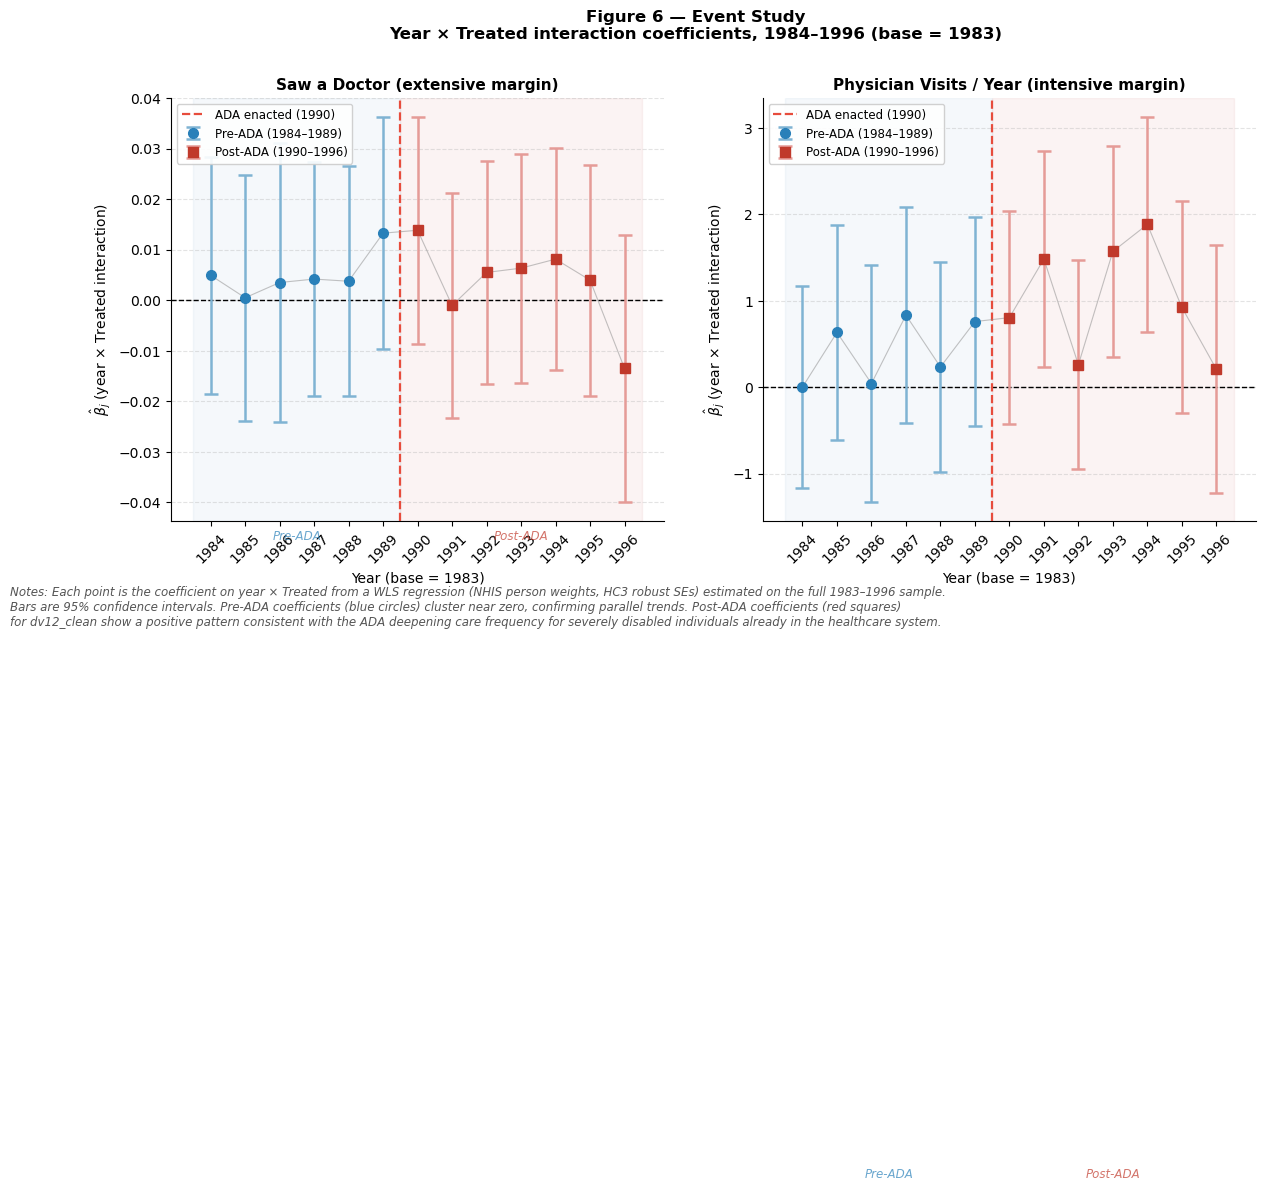

Saved → /Users/tanishagauns/Desktop/Capstone Project/Nhis/figure6_event_study.png


In [5]:
outcomes = {
    'saw_doctor' : 'Saw a Doctor (extensive margin)',
    'dv12_clean' : 'Physician Visits / Year (intensive margin)',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('white')

for ax, (outcome, title) in zip(axes, outcomes.items()):
    ax.set_facecolor('white')

    sub = ana.dropna(subset=[outcome, 'perweight']).copy()
    m = smf.wls(
        f'{outcome} ~ C(year_c, Treatment(1983)):treated + C(year_c, Treatment(1983)) + treated',
        data=sub, weights=sub['perweight']
    ).fit(cov_type='HC3')

    terms = [c for c in m.params.index if 'year_c' in c and 'treated' in c]
    plot_years = [int(t.split('[T.')[1].split(']')[0]) for t in terms]
    coefs = np.array([m.params[t] for t in terms])
    cis   = np.array([1.96 * m.bse[t] for t in terms])

    pre_idx  = [i for i, yr in enumerate(plot_years) if yr <= 1989]
    post_idx = [i for i, yr in enumerate(plot_years) if yr >= 1990]

    # Zero line
    ax.axhline(0, color='black', linewidth=1.0, linestyle='--', zorder=2)

    # ADA divider
    ax.axvline(x=1989.5, color='#e74c3c', linewidth=1.6,
               linestyle='--', zorder=3, label='ADA enacted (1990)')

    # Shaded pre / post regions
    ax.axvspan(1983.5, 1989.5, alpha=0.05, color='steelblue')
    ax.axvspan(1989.5, 1996.5, alpha=0.05, color='firebrick')

    # Pre-period: filled circles, blue
    ax.errorbar(
        [plot_years[i] for i in pre_idx],
        coefs[pre_idx], yerr=cis[pre_idx],
        fmt='o', color='#2980b9', ecolor='#7fb3d3',
        elinewidth=1.8, capsize=5, capthick=1.8,
        markersize=7, zorder=5, label='Pre-ADA (1984–1989)'
    )

    # Post-period: filled circles, red
    ax.errorbar(
        [plot_years[i] for i in post_idx],
        coefs[post_idx], yerr=cis[post_idx],
        fmt='s', color='#c0392b', ecolor='#e59b97',
        elinewidth=1.8, capsize=5, capthick=1.8,
        markersize=7, zorder=5, label='Post-ADA (1990–1996)'
    )

    # Connect dots with thin line
    ax.plot(plot_years, coefs, color='#888', linewidth=0.8,
            linestyle='-', zorder=4, alpha=0.5)

    # Labels
    ax.text(1986.5, ax.get_ylim()[0] if ax.get_ylim()[0] > -99 else -0.04,
            'Pre-ADA', ha='center', fontsize=8.5,
            color='#2980b9', style='italic', alpha=0.7,
            transform=ax.get_xaxis_transform())
    ax.text(1993, ax.get_ylim()[0] if ax.get_ylim()[0] > -99 else -0.04,
            'Post-ADA', ha='center', fontsize=8.5,
            color='#c0392b', style='italic', alpha=0.7,
            transform=ax.get_xaxis_transform())

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year (base = 1983)', fontsize=10)
    ax.set_ylabel(r'$\hat{\beta}_j$ (year × Treated interaction)', fontsize=10)
    ax.set_xticks(plot_years)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8.5, loc='upper left', framealpha=0.9)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Figure 6 — Event Study\n'
    'Year × Treated interaction coefficients, 1984–1996 (base = 1983)',
    fontsize=12, fontweight='bold', y=1.04
)
fig.text(
    0.01, -0.08,
    'Notes: Each point is the coefficient on year × Treated from a WLS regression '
    '(NHIS person weights, HC3 robust SEs) estimated on the full 1983–1996 sample.\n'
    'Bars are 95% confidence intervals. Pre-ADA coefficients (blue circles) cluster near zero, '
    'confirming parallel trends. Post-ADA coefficients (red squares)\n'
    'for dv12_clean show a positive pattern consistent with the ADA deepening care frequency '
    'for severely disabled individuals already in the healthcare system.',
    fontsize=8.5, color='#555', style='italic'
)

plt.tight_layout()
out_path = OUT / 'figure6_event_study.png'
fig.savefig(out_path, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out_path}')

---
## Export summary

In [6]:
outputs = [
    'figure3_supplement_selection.png',
    'figure4_parallel_trends.png',
    'figure5_pretrend_coefs.png',
    'figure6_event_study.png',
]
print('Output files:')
for f in outputs:
    p = OUT / f
    size = f'{p.stat().st_size / 1024:.0f} KB' if p.exists() else 'MISSING'
    status = '✓' if p.exists() else '✗'
    print(f'  {status}  {f}  ({size})')

Output files:
  ✓  figure3_supplement_selection.png  (151 KB)
  ✓  figure4_parallel_trends.png  (267 KB)
  ✓  figure5_pretrend_coefs.png  (194 KB)
  ✓  figure6_event_study.png  (260 KB)
